# Aeromagnetic data QC

This notebook demonstrates the use of functions to perform QC of aeromagnetic data.

Here we demonstrate their use on the xxx survey data.

Ensure you have run the `xxx` notebook first so that the xxx data are prepared for review.

___

First, import the required python packages, ...

In [1]:
from pathlib import Path
import pegasusQC as qc

... then set the path to the geowhizz files.

This is all very much step by step to illustrate the process, and you can certainly compress some of these steps in your own work.

In [2]:
dx = Path(r'./MagData/FD013_Mag.xyz')
dh = dx.with_suffix(".hdf5")

In [3]:
if not dh.exists():
    %run ./Prepare_AeromagData.ipynb

We will need channel names later so let's report them now.

In [4]:
qc.reportChannels(dh, verbose=True)

Whizz Version 1.0

17 channels:

  channel              units          description
--------------------------------------------------
  COMPMAG              nT             
  DCMAG                nT             
  DEM                  m              
  DIURNAL              nT             
  DOY                                 
  FLIGHT                              
  FTIME                               
  IGRFMAG              nT             
  LAT                  deg            
  LINE                                
  LONG                 deg            
  LVLDMAG              nT             
  MGA-X                m              
  MGA-Y                m              
  MGA-Z                m              
  MSL-Z                m              
  YEAR                                


___

A standard technical specification is the requirement that the basemag diurnal monitoring data, collected while each line is sampled, not deviate from a straight-line chord of a certain time span by more than a given number of nanoTesla.

The `checkDiurnal` function checks the data for such deviations in the given channel, deviations being less than `rangeLimit` over chords whose time span is `nSamples` long (as number of fids or samples).

  Checked 12 lines, 1 failed.


  L 2463.040: Diurnal for DIURNAL at sample number 3431 diverges from chord by 0.03, exceeding 0.0 - FAIL


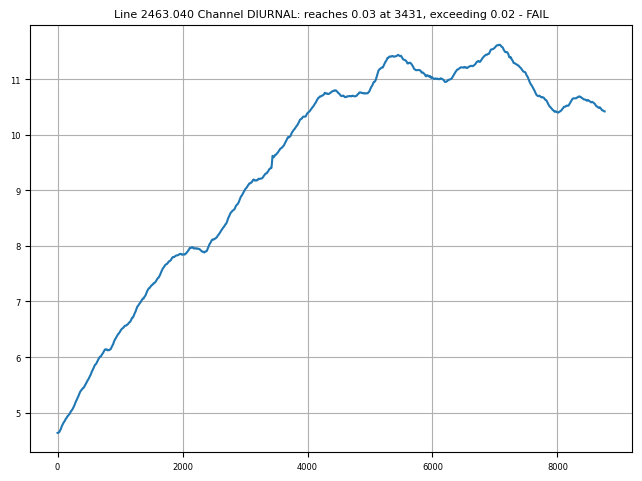

In [5]:
qc.checkDiurnal(dh, 'DIURNAL', lines=[],
                rangeLimit = 0.02, nSamples = 8, plot_flag=True)

___

The standard check for noise in aeromagnetic data is the 4th difference.

The function `checkTCDiff4` checks the total magnetic field fourth difference channel in a whizzFile against the specification that the peak to peak variation over a set number of samples must not exceed some peak value. If no fourth difference channel is supplied, then the raw magnetic data channel may be used, and its 4th difference will be calculated by the function.

For a joint gravity-magnetic survey 4th difference noise is typically higher than for a solely magnetometer survey. In the former case, A typical requirement might set the limit to 0.02 nT over 3000 smples.

The `plot_flag` and `verbose` Boolean parameters control whether the results are plotted, and whether a verbose report is given, as usual.

  Checked 12 lines, 0 failed.

Line 2463.040: exceedances = 146 < 3000 - PASS
Line 2469.000: exceedances = 13 < 3000 - PASS


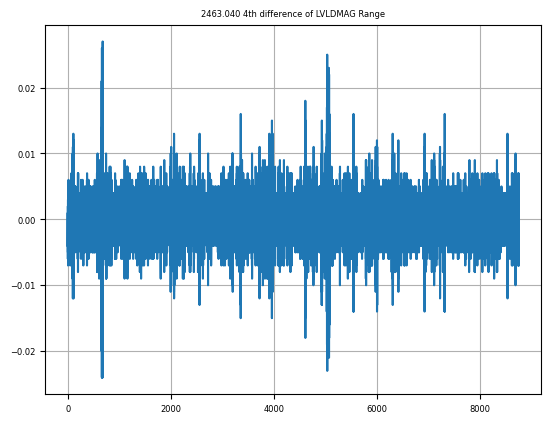

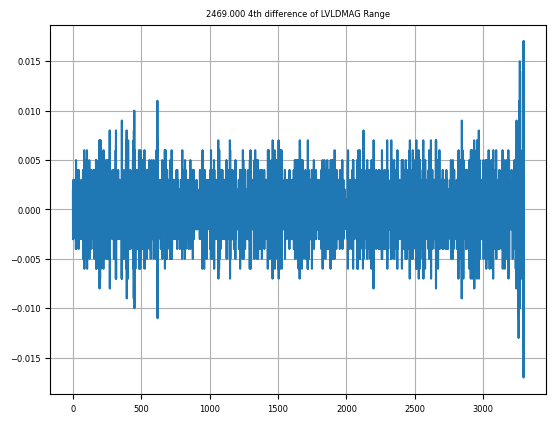

In [6]:
qc.checkTCDiff4(dh, TCDiff4='', rawMag='LVLDMAG', lines=[],
                limit=0.01, plot_flag=True, verbose=True)

___

It is useful to check the power spectrum of the magnetic data because periodic noise sources can occur and these are often not seen in the standard 4th difference measure. This can be performed at each stage of processing, or just on the raw magnetic data and the final magnetic data. The power spectrum should not have any signs of harmonic signal.

In the example below, there are no spikes in the spectrum above $10^{-3}$ so all okay.

Of 12 lines in database, 10 will be processed.
The first 2634 samples from each line will be used.


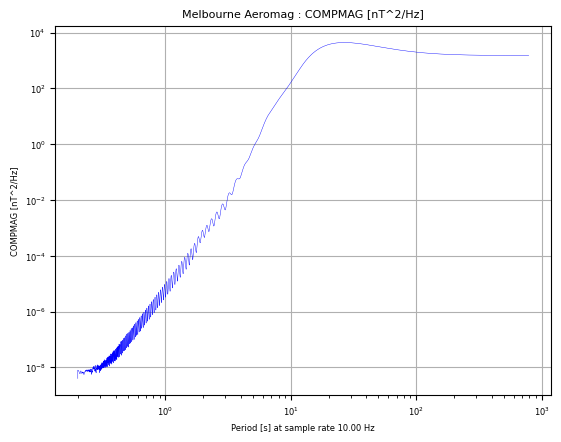

In [7]:
qc.psdChannel(dh, 'COMPMAG', flightLines=[], shortestPeriod=0.0, minlinelenkm=15.0, verbose=False)

___

There are other QC checks that should be performed but for which no QC function exists.

Magnetic compensation flights should be:

1. on a magnetically quiet location;
2. at high enough altitude to avoid short wavelength magnetic signal;
3. at a location where local magnetic field variations are less than 100 nT;
4. at a location where the magnetic field gradient is small;
5. with sufficient manoeuvre variation  to give more than 1000 nT signal in each fluxgate magnetometer;
6. over a flight path that forms a complete square;
7. with a fourth difference of the total field less than 0.1 nT over a 1000 m window;
8. delivering a figure-of-merit less than 2 nT.

A magnetometer lag calibration should be performed. Criteria are: ?##?

A magnetomer heading test should be performed. Criteria are: ?##?